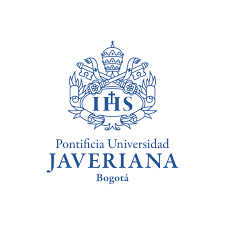
***Pontificia Universidad Javeriana***
# **High Volume Data Processing**

#### **Dataset:** [Uc Urvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)


### Workshop: **Metrics & Machine Learning with PySpark**

Author: Diego Felipe Céspedes

Start Date: 04/28/2026

## **Objectives**

- Start Spark Session
- Load Bank Data
- Data Understanding
- Data Cleaning

In [1]:
##Import General libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import *

##Spark specialized libraries

import findspark
findspark.init()
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql import Row
from pyspark.sql.types import *

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve, auc

In [2]:
configure = SparkConf()

configure.setAppName("Bank_Cespedes_Spark")

sparkC = SparkSession.builder.config(conf=configure).getOrCreate()

SQLContext(sparkContext=sparkC.sparkContext, sparkSession=sparkC)

sparkContextoC = sparkC.sparkContext.getOrCreate()

print("Session Loaded: DataProcessing04")

sparkContextoC

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 20:45:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Session Loaded: DataProcessing04


<SparkContext master=spark://10.43.97.187:7077 appName=Bank_Cespedes_Spark>

In [3]:
### Import dataset

df00 = sparkC.read.format("csv").option("header", "true").option("sep",";").load("hdfs://10.195.34.34:9000/csv/bank-full.csv") 
df00.show(5)

[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

# Data Understanding

In [4]:
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



### Comments
- The variables to be converted to integers are: age, balance, day, duration, campaign, pdays, previous
- The variables to be converted to binary are: default, housing, loan, and
- The rest are left as Strings since they are categorical; OneHotEncoder can be used for this purpose.
- The target variable is y

In [5]:
##Changing variables to type int

df01 = df00.withColumn("age", df00.age.cast("int"))
df01 = df01.withColumn("balance", df00.balance.cast("int"))
df01 = df01.withColumn("day", df00.day.cast("int")) 
df01 = df01.withColumn("duration", df00.duration.cast("int")) 
df01 = df01.withColumn("campaign", df00.campaign.cast("int")) 
df01 = df01.withColumn("pdays", df00.pdays.cast("int")) 
df01 = df01.withColumn("previous", df00.previous.cast("int"))

In [6]:
### Size of data
print(f"There is a total of {df00.count()} records")

[Stage 2:=============================>                             (1 + 1) / 2]

There is a total of 45211 records


In [7]:
df01.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



### Checking target variable balance

In [8]:
## Imbalance might imply bias
total = df01.count() # total data
df_Y = df01.groupBy("y").count()
auxPD = df_Y.withColumn("Percentage", df_Y["count"]*100/total) # How 'y' is distributed
auxPD.show() # Se muestra en un dataframe

[Stage 8:=============================>                             (1 + 1) / 2]

+---+-----+------------------+
|  y|count|        Percentage|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



### Comments

- Observing the balance on the labels or the target column, we see:
- The variable y is binary
- The minority class is "yes" with 11.69% and 5289 records
- The majority class is "no" with 88.30% and 39922 records
- The database is quite unbalanced; this is a problem that will be resolved later
   

In [9]:
# Checking the dataset's statistics

df01.describe().toPandas()

26/05/25 20:45:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


## Checking categorical variables

In [10]:
col_cat = ["job","marital","education","default","housing","loan","contact","month","poutcome","y"]

df01.groupBy("job").count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+



- Distribution skewness: The dataset is heavily concentrated in the blue-collar (9,732) and management (9,458) sectors, closely followed by technician (7,597). Together, these represent the vast majority of the sample.

- Presence of noise (unknown): There are 288 records categorized as "unknown." Although this is a low percentage, a decision will need to be made during the cleaning stage regarding whether to impute them (e.g., using the mode), remove them, or retain them as a valid category.

- Minority groups: Sectors such as student (938) and housemaid (1,240) are very underrepresented, which could hinder the model from learning robust patterns for these specific profiles.

In [11]:
df01.groupBy("marital").count().show()

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+



- The vast majority of clients are married (married: 27,214), doubling the number of single people (single: 12,790) and far exceeding the number of divorced people (divorced: 5,207).

In [12]:
df01.groupBy("education").count().show()

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+



- The secondary education level predominates (23,202), followed by the tertiary level. Pay attention to the "unknown" category (1,857); this represents a considerable amount of missing data that should be addressed before training the model.

In [13]:
df01.groupBy("default").count().show()

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+



- There is a critical class imbalance. The vast majority of the sample does not register defaults (no: 44,396) compared to only 815 cases that do (yes). This variable contributes very little variability, and the model could ignore the minority class if not managed properly.

In [14]:
df01.groupBy("housing").count().show()

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+



- It is well balanced, having a slight majority of clients with active home loans (yes: 25,130) compared to those who do not (no: 20,081).

In [15]:
df01.groupBy("loan").count().show()

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+



- Shows a clear class imbalance. The vast majority of clients do not have an active personal loan (no: 37,967) compared to those who do (yes: 7,244). This tells us that the typical customer targeted in this campaign does not carry secondary personal debt.

In [16]:
df01.groupBy("contact").count().show()

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+---------+-----+



- The dominant channel is mobile (cellular: 29,285), while landlines (telephone: 2,906) are marginal. However, there is a critical red flag with the unknown category (13,020), which makes up nearly 30% of the data. Because it represents such a massive chunk, simply dropping these records or mishandling them could introduce significant bias into your model.

In [17]:
df01.groupBy("month").count().show()

+-----+-----+
|month|count|
+-----+-----+
|  jun| 5341|
|  aug| 6247|
|  may|13766|
|  feb| 2649|
|  mar|  477|
|  oct|  738|
|  jul| 6895|
|  nov| 3970|
|  apr| 2932|
|  dec|  214|
|  jan| 1403|
|  sep|  579|
+-----+-----+



- This feature reveals strong seasonality and campaign concentration. The peak of the marketing campaign happens heavily in may (13,766), followed by a steady volume during the summer months (jul, aug, jun). Conversely, winter months like dec (214) and mar (477) have almost no activity. This high imbalance means the model might associate certain months heavily with the target outcome just due to the sheer volume of calls made.

In [18]:
df01.groupBy("poutcome").count().show()

+--------+-----+
|poutcome|count|
+--------+-----+
| success| 1511|
| unknown|36959|
|   other| 1840|
| failure| 4901|
+--------+-----+



- This variable presents a severe data quality issue. The vast majority of the records are unknown (36,959), which represents over 80% of the dataset. While a success (1,511) or failure (4,901) from a past campaign is incredibly predictive, this massive amount of missing information means you will likely have to treat unknown as its own separate category or consider dropping the feature entirely if it introduces too much noise.

## **Numeric Variables Graphs**
- Each numeric variable is grouped and graphed

Text(0.5, 1.0, 'Frecuency by age')

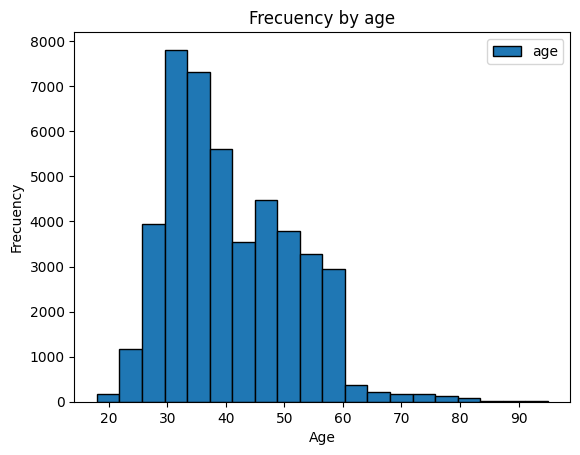

In [19]:
col_int = ["age","balance","day","duration","campaign","pdays","previous"]

histGra = df01.select("age").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor = 'black')
plt.xlabel("age".capitalize())
plt.ylabel("Frecuency")
plt.title(f"Frecuency by age")

### Comments
------------
- The vast majority of the targeted individuals are concentrated between their late 20s and late 40s. There is a clear peak concentration in the 30 to 35 age range, which represents the most heavily active demographic group in this dataset. There is a noticeable decline after the age 60.

Text(0.5, 1.0, 'Frecuency by balance')

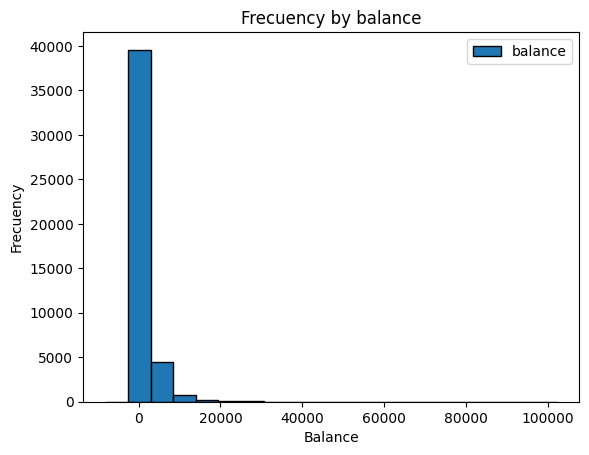

In [20]:
histGra = df01.select("balance").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor = 'black')
plt.xlabel("balance".capitalize())
plt.ylabel("Frecuency")
plt.title(f"Frecuency by balance")

### Comments
------------
- The vast majority of the data (nearly 40,000 observations) is densely concentrated in a single initial bin around 0. This indicates that most targeted individuals have low or near-zero bank balances. The very long, sparse tail going toward high values suggests the presence of extreme outliers. For machine learning algorithms (like linear models or distance-based algorithms), this severe skewness and outlier presence meanswe might need to apply a transformation.

Text(0.5, 1.0, 'Frecuency by day')

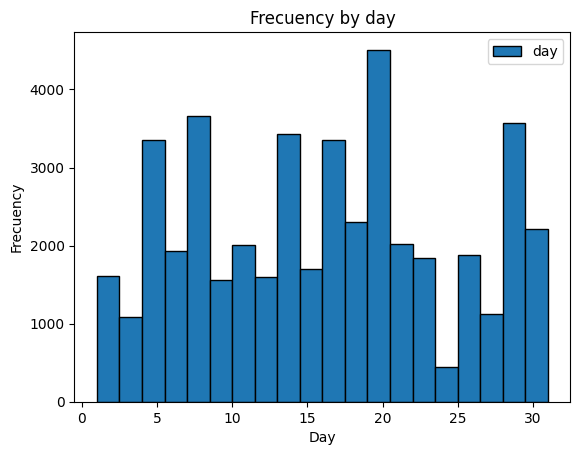

In [21]:
histGra = df01.select("day").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor = 'black')
plt.xlabel("day".capitalize())
plt.ylabel("Frecuency")
plt.title(f"Frecuency by day")

### Comments
------------
- The data spreads relatively evenly across the entire month (from day 1 to 31) with multiple distinct peaks. There is a massive, sudden drop-off in activity around the 24th day of the month, where the frequency plummets drastically compared to the rest of the distribution.

Text(0.5, 1.0, 'Frecuency by duration')

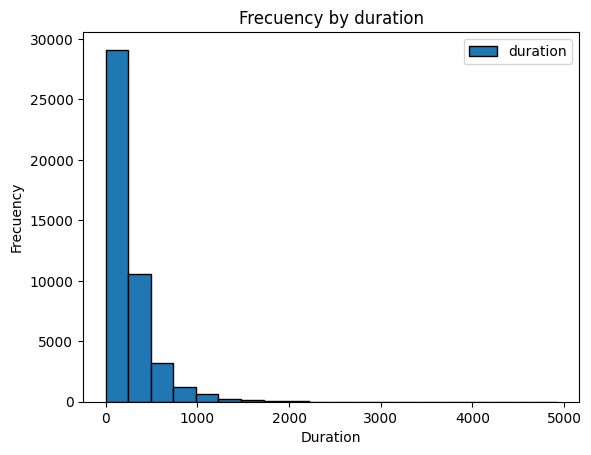

In [22]:
histGra = df01.select("duration").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor = 'black')
plt.xlabel("duration".capitalize())
plt.ylabel("Frecuency")
plt.title(f"Frecuency by duration")

### Comments
------------
- The clear majority of calls, nearly 30,000 observations, are clustered in the first bin between 0 and roughly 250 seconds. This shows that most marketing interactions are very brief, lasting under 4 minutes. The tail drags on all the way up to nearly 5,000 seconds (almost an hour and twenty minutes). These extreme values represent massive outliers.

Text(0.5, 1.0, 'Frecuency by campaign')

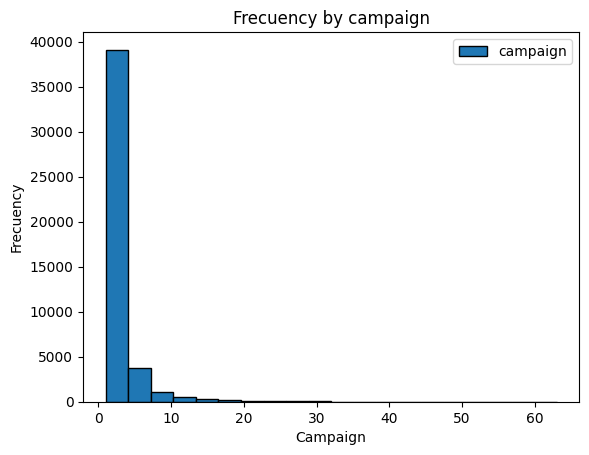

In [23]:
histGra = df01.select("campaign").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor = 'black')
plt.xlabel("campaign".capitalize())
plt.ylabel("Frecuency")
plt.title(f"Frecuency by campaign")

### Comments
------------
The absolute majority of the data, nearly 40,000 observations, is concentrated in the very first bin (1 to 3 contacts). This indicates that the operational strategy successfully resolves most cases within just a few interactions.

Text(0.5, 1.0, 'Frecuency by pdays')

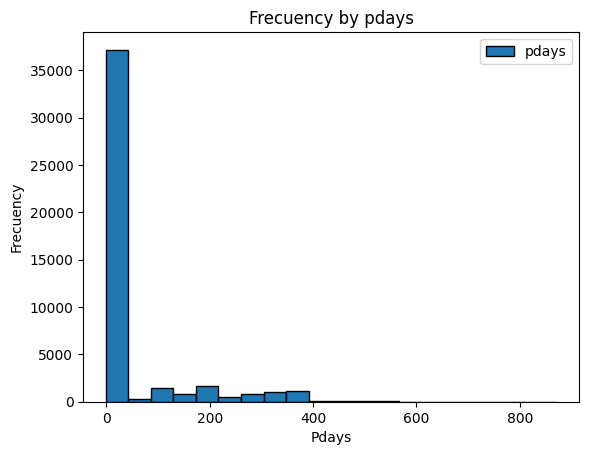

In [24]:
histGra = df01.select("pdays").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor = 'black')
plt.xlabel("pdays".capitalize())
plt.ylabel("Frecuency")
plt.title(f"Frecuency by pdays")

### Comments
------------

- The pdays variable (the number of days that passed by after the client was last contacted from a previous campaign) shows an extreme concentration in the first bin near 0. A value of -1 means the client has never been contacted before, this might give us trouble with a maachine learning model.

Text(0.5, 1.0, 'Frecuency by previous')

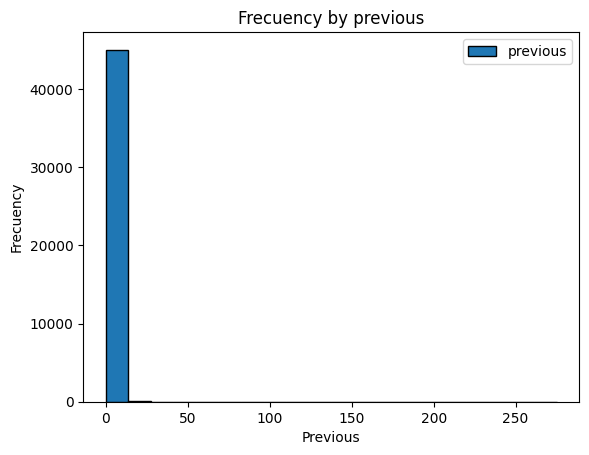

In [25]:
histGra = df01.select("previous").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor = 'black')
plt.xlabel("previous".capitalize())
plt.ylabel("Frecuency")
plt.title(f"Frecuency by previous")

### Comments
------------

The previous variable (representing the number of contacts performed before this campaign for a specific client) displays a massive concentration at exactly 0. This single bin contains over 45,000 observations, confirming that the vast majority of the target audience are entirely new prospects with no prior touchpoints.

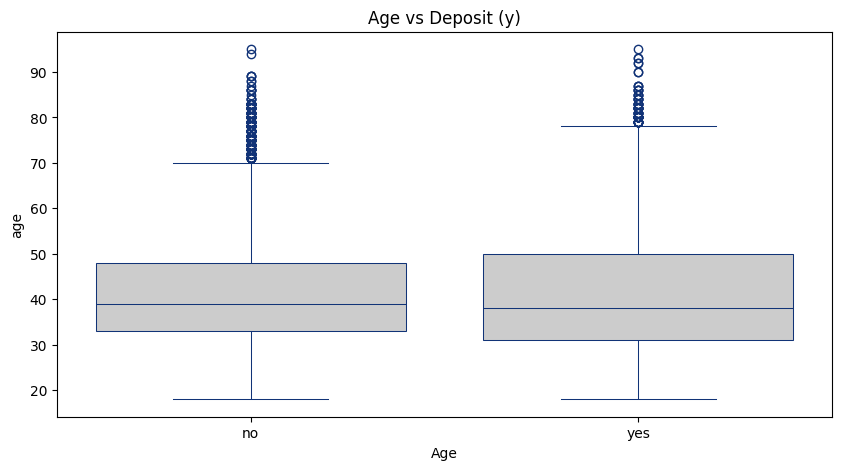

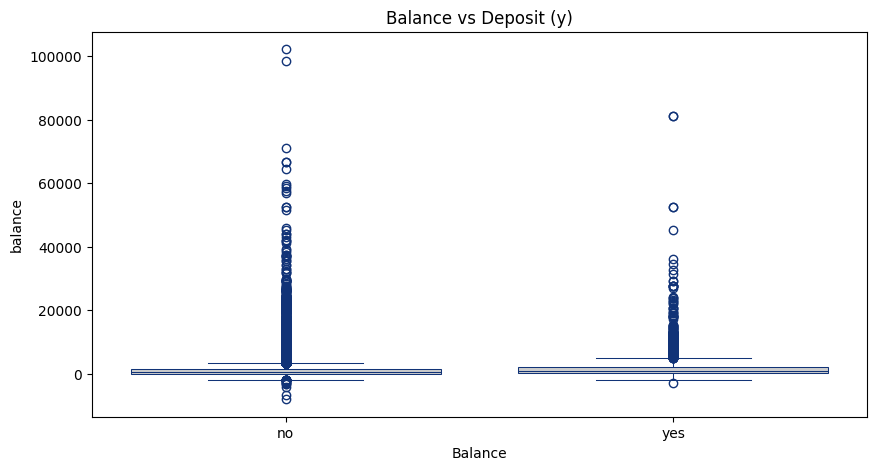

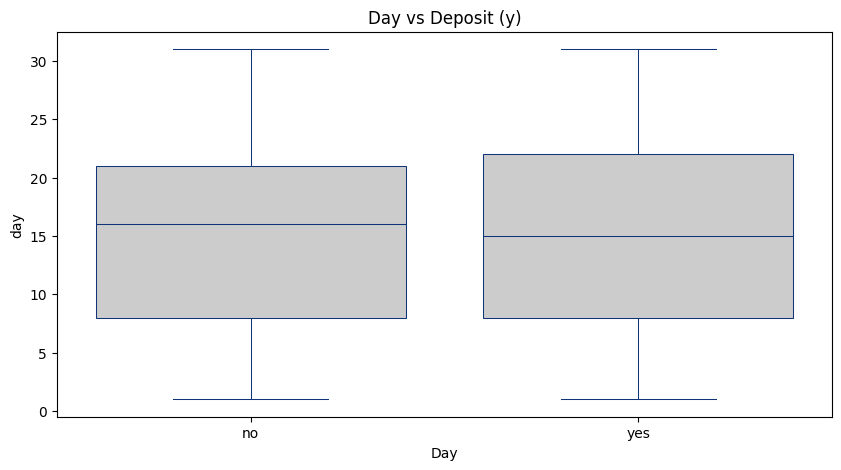

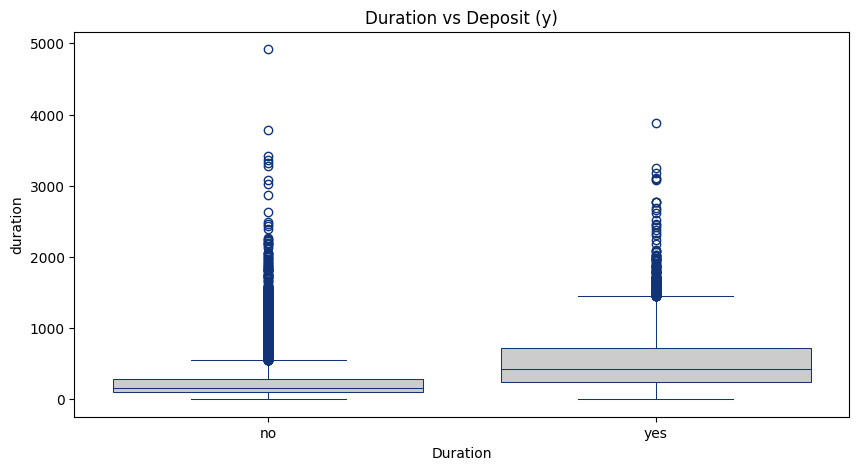

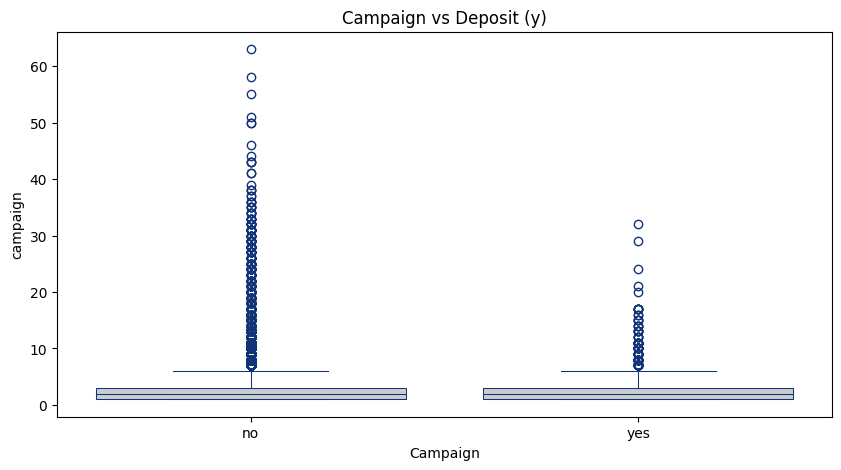

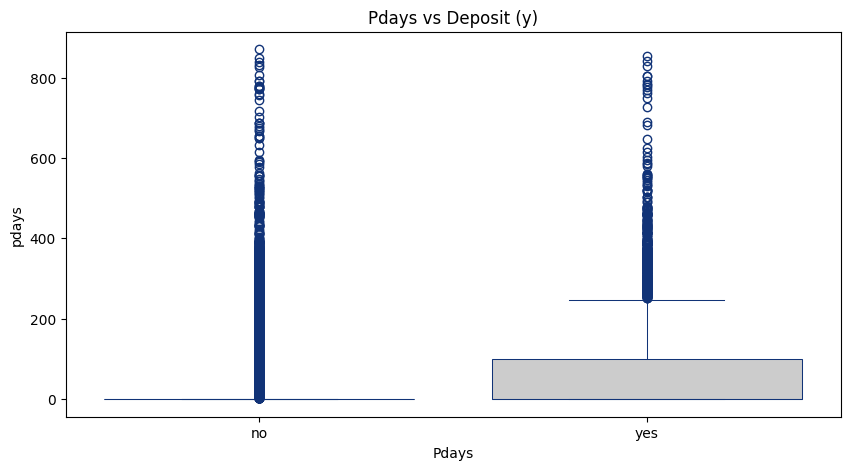

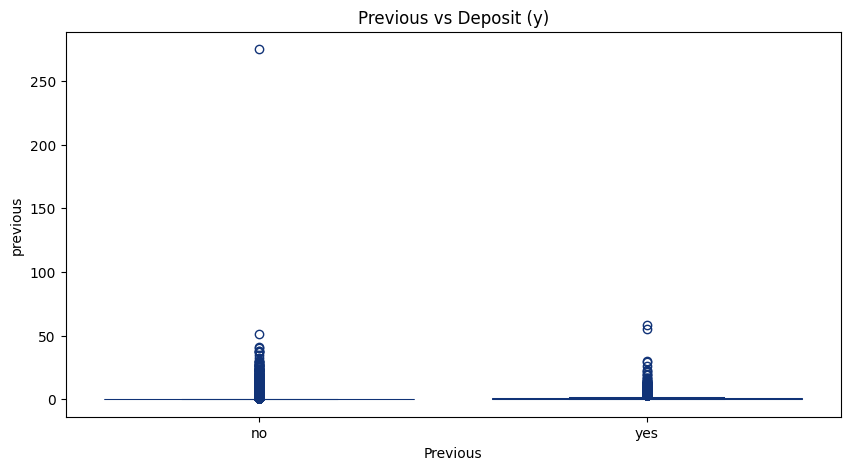

In [26]:
#El objetivo de los graficas es observar la tendencia de las variables e identificar outliers

for i in col_int:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='y', y=i, color=".8", linecolor="#137",linewidth=0.75,data=df01.toPandas())
    plt.title(f"{i.capitalize()} vs Deposit (y)")
    plt.xlabel(i.capitalize())
    plt.show()

### Comments
------------

- The combined analysis of the plots shows that the variables in this banking dataset exhibit strong imbalances and right-skewness, which will require specific data transformations prior to machine learning modeling. While sociodemographic and scheduling features like customer age (age) and the specific day of contact (day) show virtually no visual variation between clients who accept or decline the deposit, variables tied to previous campaign history (pdays) and, most critically, the duration of the final call (duration) emerge as the clearest discriminators and hold the highest predictive power for identifying a successful conversion.

## Data Understanding: Correlation Matrix

In [27]:
### Se requiere cambiar la columna "y" de si o no a 0 y 1
### También se requiere incorporarla al dataframe numérico

col_int = ["age","balance","day","duration","campaign","pdays","previous"]

dfAuxNum = df01.select(col_int + ["y"])
dfAuxNum = dfAuxNum.withColumn("y", F.when(dfAuxNum['y'] == 'yes', 1).otherwise(0))
dfAuxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [28]:
### El anterior dataframe auxiliar se convierte en un VectorAssembler de 'feature'
### (fijese que ese incorpora la variable 'y' con los numericos para hacer el vector)
### la idea es que con el vector se pueda representar escalada/normalizada la matriz de correlación

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

ensamblador = VectorAssembler(inputCols = dfAuxNum.columns, outputCol = 'features')
## Normalizado y Escalado
dfNumVector = ensamblador.transform(dfAuxNum).select('features')

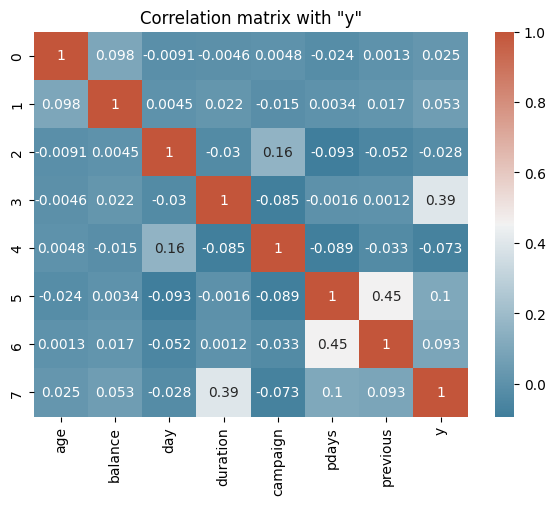

In [29]:
### Se grafica la matriz de correlación: se tiene en cuenta que los datos son ensamblados
matrizCorr = Correlation.corr(dfNumVector, 'features').head()

### Se procede a pintar la matriz de correlación
vectorCorr = matrizCorr[0].toArray()

### Se crea un objeto dataframe con el arreglo anterior de Correlación de Pearson
dfCorrelation = pd.DataFrame(vectorCorr, columns = dfAuxNum.columns)

plt.figure(figsize=(7,5))
plt.title('Correlation matrix with "y"')
cmapC = sns.diverging_palette(230,20,as_cmap = True)
sns.heatmap(dfCorrelation,
           annot= True,
           cmap = cmapC)
plt.show()

### Comments

- The pdays variable has a high corrrelation, meaning it posseses a risk of multicolinearity. Because of this, it's better to remove it from the model.

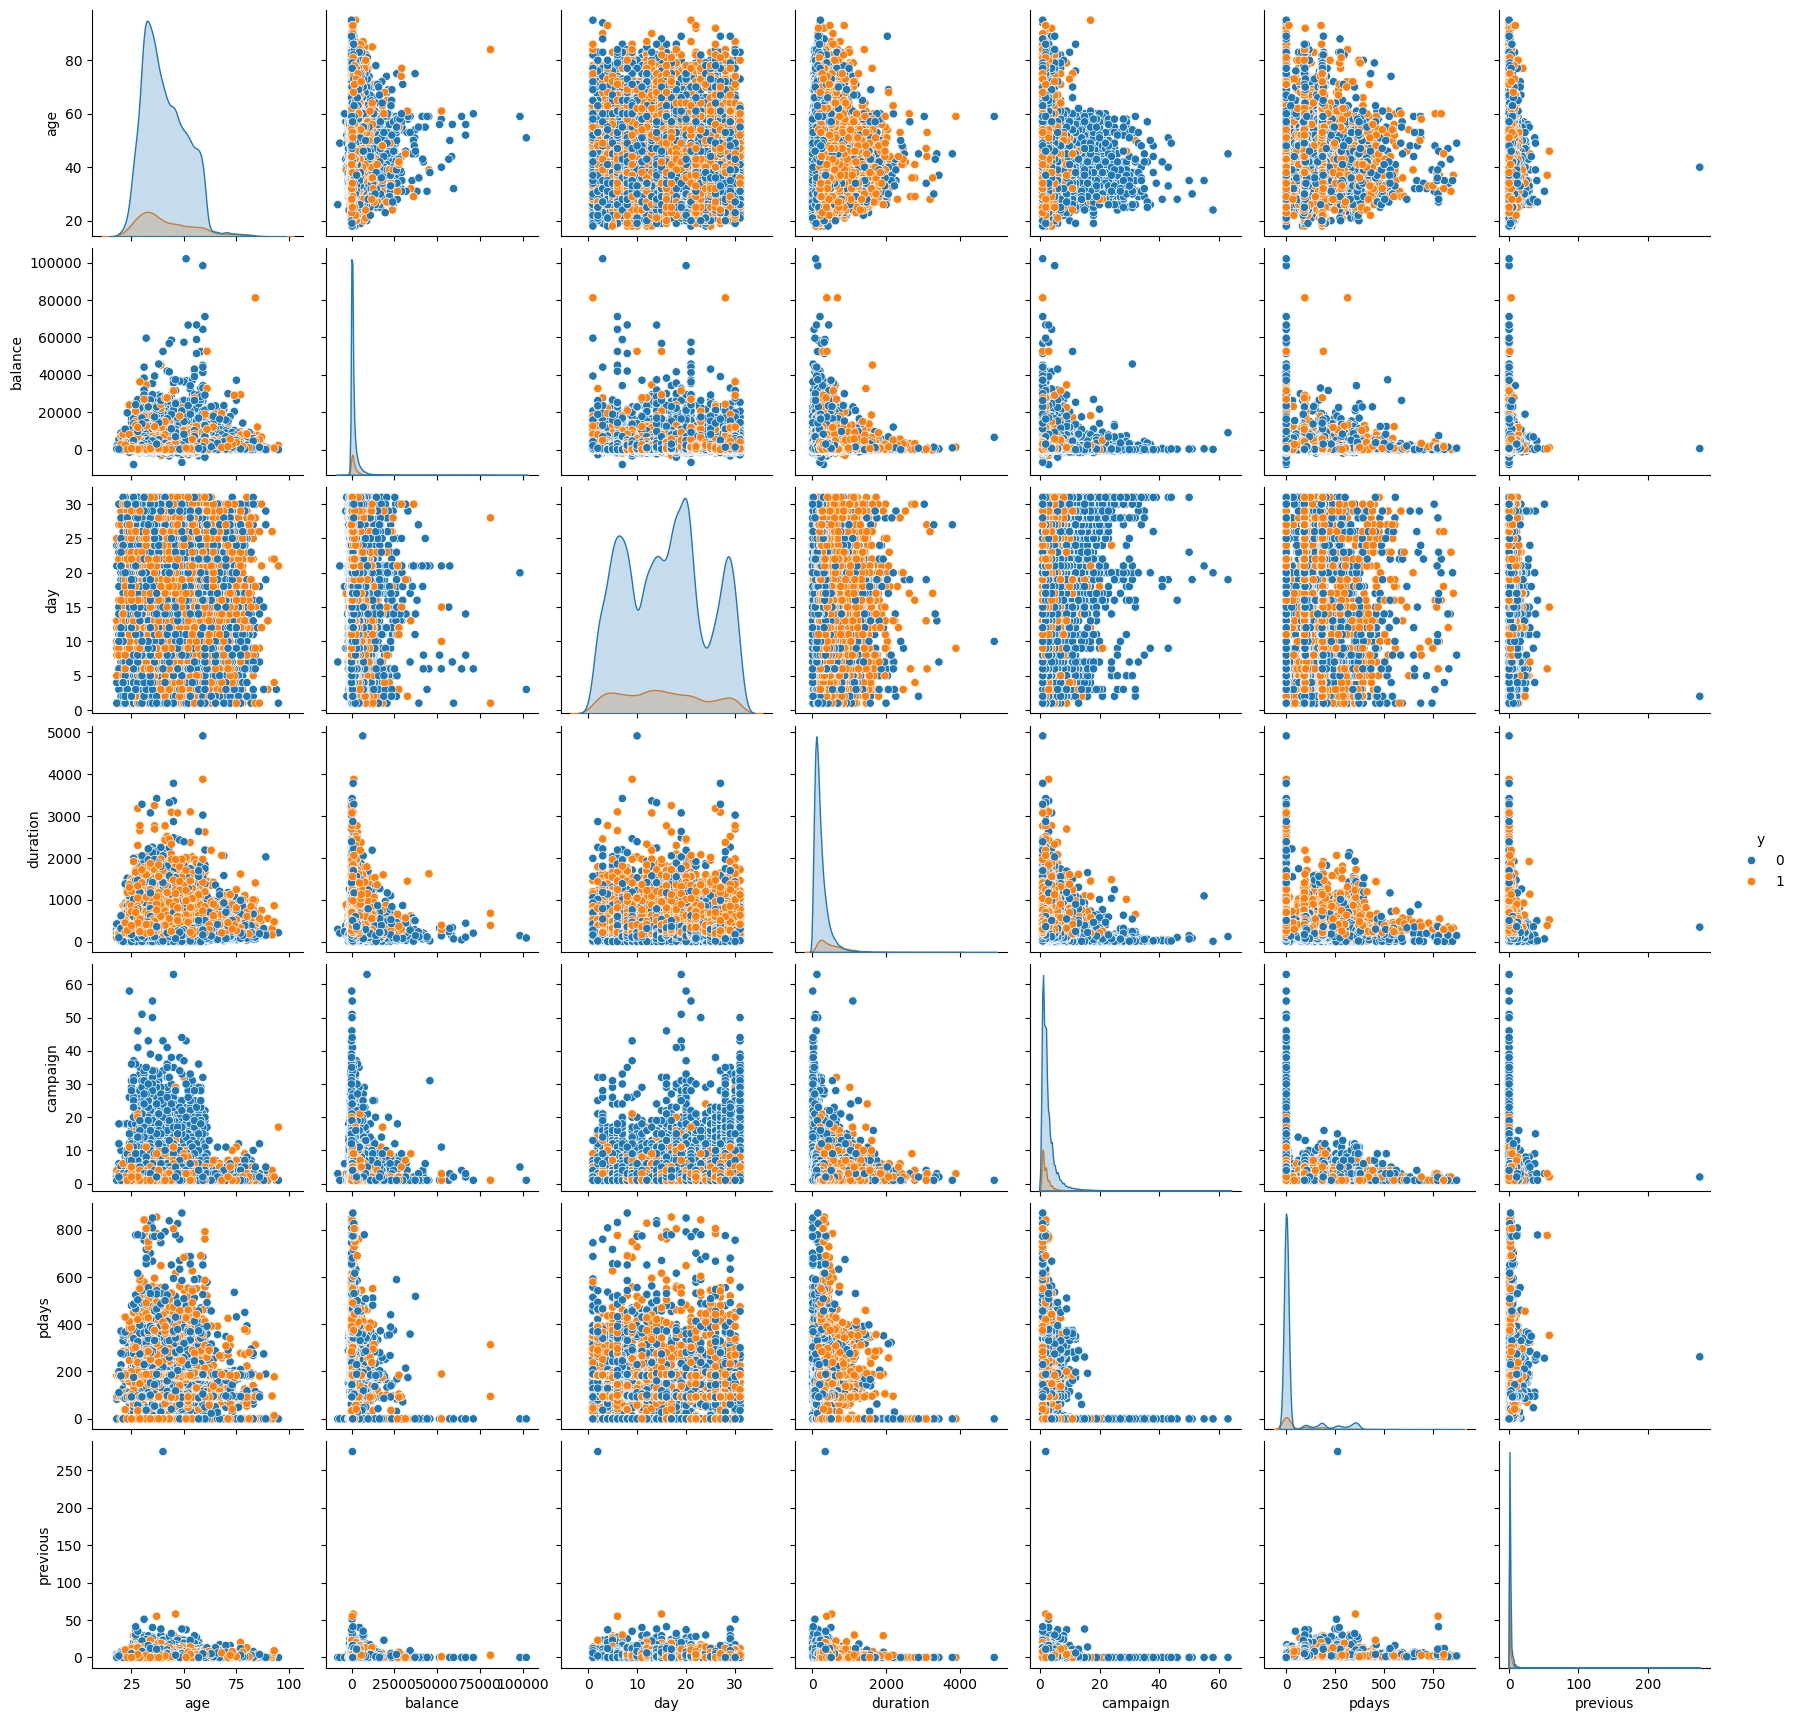

In [30]:
## Se requiere hacer un grafico sobre todas las variables 

sns.pairplot(dfAuxNum.toPandas(), kind='scatter', hue='y')
plt.show()

### Graficas de Pastel

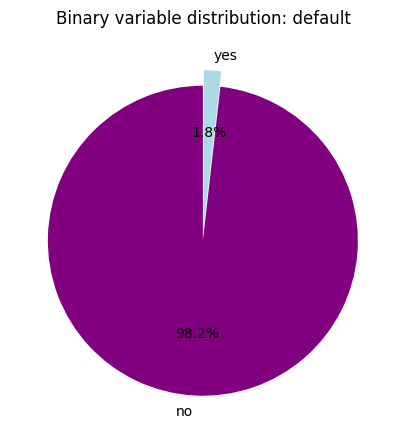

In [31]:
explode = (0.1,0)
colors = ['purple','lightblue']

plt.figure(figsize=(5,6))
cantBin = df01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle =90)
plt.title(f'Binary variable distribution: default')
plt.ylabel('')
plt.show()

#### Comments
------

- This variable exhibits an extreme class imbalance. An overwhelming 98.2% of the sample has no history of credit default, leaving a tiny 1.8% minor class who do. Because there is virtually no variance in this feature, many machine learning models may struggle to extract meaningful patterns from it without class-weighting techniques.

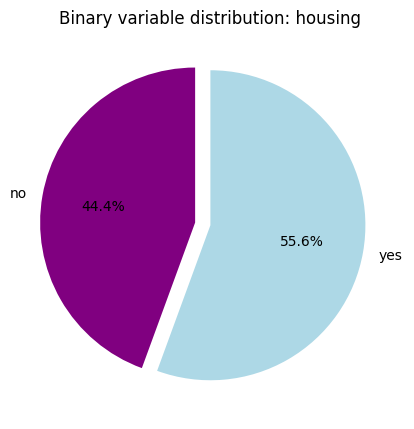

In [32]:
explode = (0.1,0)
colors = ['purple','lightblue']

plt.figure(figsize=(5,6))
cantBin = df01.groupBy('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle =90)
plt.title(f'Binary variable distribution: housing')
plt.ylabel('')
plt.show()

#### Comentarios
------

- This is the most well-balanced feature among the binary variables. With 55.6% of clients holding a housing loan and 44.4% without one, this feature provides a healthy split that will allow algorithms to easily test for distinct behaviors across both groups without risk of class bias.

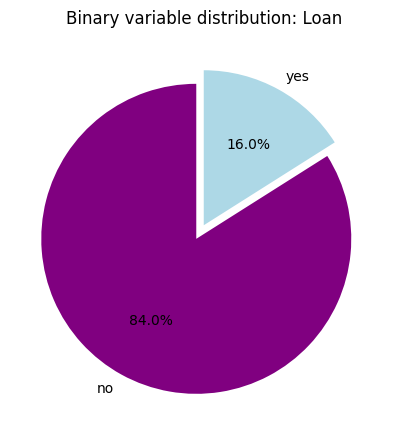

In [33]:
plt.figure(figsize=(5,6))
cantBin = df01.groupBy('Loan').count().toPandas()
cantBin.set_index('Loan')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle =90)
plt.title(f'Binary variable distribution: Loan')
plt.ylabel('')
plt.show()

#### Comentarios
------

- This feature displays a moderate imbalance. A significant majority of 84.0% of clients do not hold a personal loan, while 16.0% do. While it is clearly skewed toward the "no" category, a 16% representation still provides enough volume for models to effectively segment the customer profile.

## Multidimensional Categorical Variables: Job, Marital, Education, Contact, Month

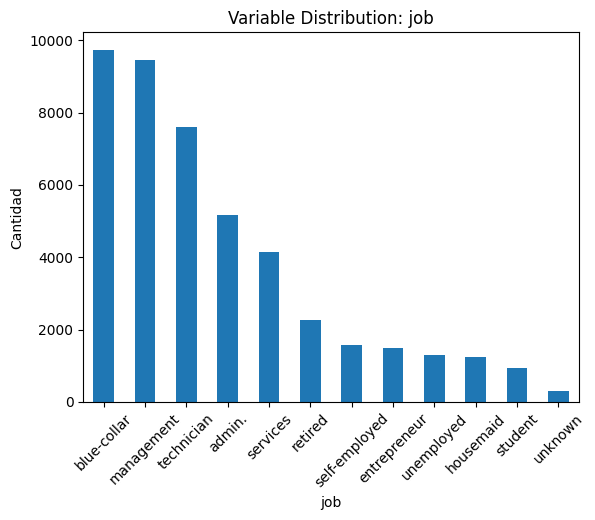

In [34]:
cantMulti = df01. groupBy('job').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti= cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='job', y='count', legend=None)
plt.xlabel('job')
plt.ylabel('Cantidad')
plt.title(f'Variable Distribution: job')
plt.xticks(rotation=45)
plt.show()


#### Comments
------

- Diverse categorical distribution with 12 distinct classes. It is heavily dominated by working-class and corporate profiles, with blue-collar and management taking the top spots (both approaching nearly 10,000 records each), closely followed by technician

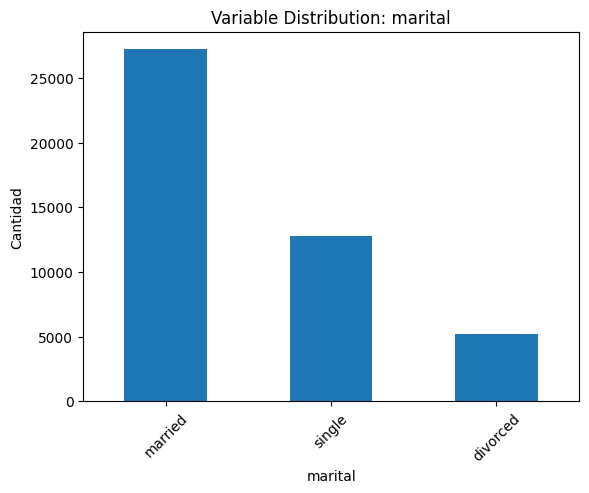

In [35]:
cantMulti = df01. groupBy('marital').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti= cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='marital', y='count', legend=None)
plt.xlabel('marital')
plt.ylabel('Cantidad')
plt.title(f'Variable Distribution: marital')
plt.xticks(rotation=45)
plt.show()


#### Comments
------
- This feature reveals a clear majority group, married individuals dominate the sample by a massive margin (surpassing 25,000 observations), doubling the size of the single group (around 12,500), while divorced remains the smallest segment at 5,000.

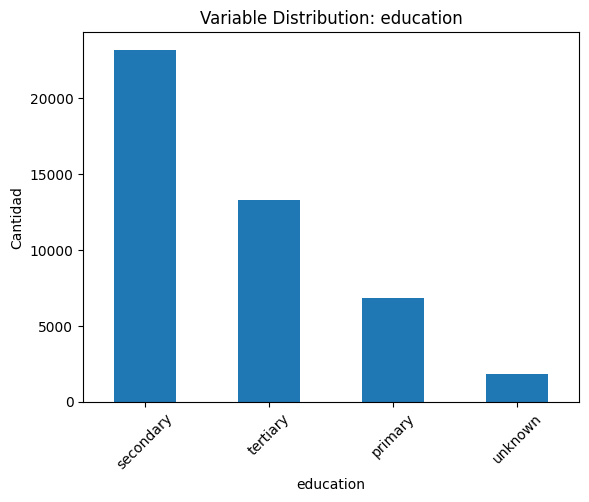

In [36]:
cantMulti = df01. groupBy('education').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti= cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='education', y='count', legend=None)
plt.xlabel('education')
plt.ylabel('Cantidad')
plt.title(f'Variable Distribution: education')
plt.xticks(rotation=45)
plt.show()

#### Comments
------
- The educational background of the target audience follows a typical pyramid distribution. The vast majority of individuals have a secondary education level (over 20,000 records), followed by tertiary (around 13,000) and primary (under 7,000).

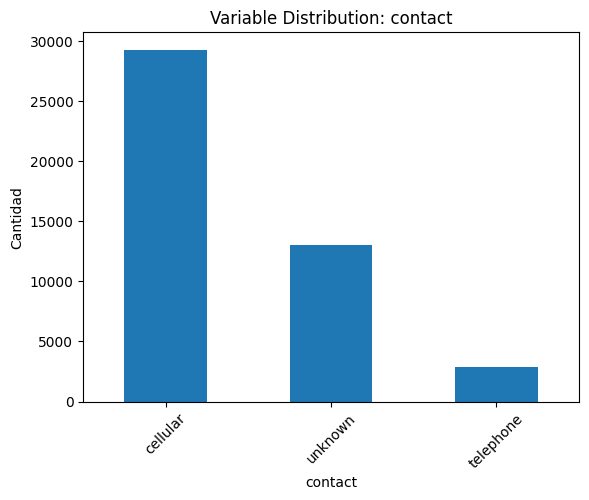

In [37]:
cantMulti = df01. groupBy('contact').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti= cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='contact', y='count', legend=None)
plt.xlabel('contact')
plt.ylabel('Cantidad')
plt.title(f'Variable Distribution: contact')
plt.xticks(rotation=45)
plt.show()

#### Comments
------
- Cellular is by far the preferred method of contact, accounting for the vast majority of the interactions (approaching 30,000 records). There is a substantial unknown category with over 12,000 records, indicating a significant chunk of missing metadata regarding the communication channel.

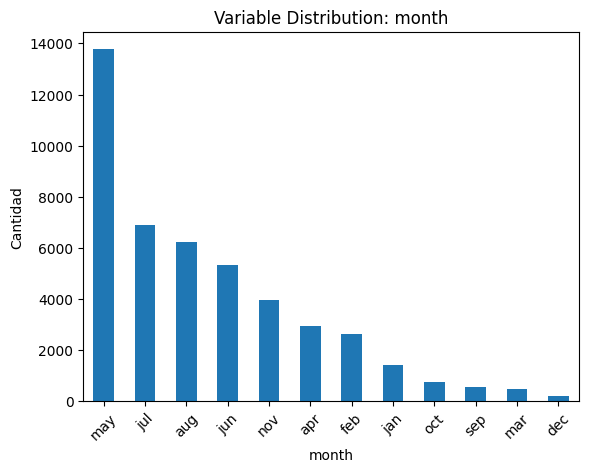

In [38]:
cantMulti = df01. groupBy('month').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti= cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='month', y='count', legend=None)
plt.xlabel('month')
plt.ylabel('Cantidad')
plt.title(f'Variable Distribution: month')
plt.xticks(rotation=45)
plt.show()

#### Comments
------
- The month of may exhibits an enormous peak that completely dominates the dataset, followed by a secondary plateau of sustained activity across the summer months (jul, aug, and jun).

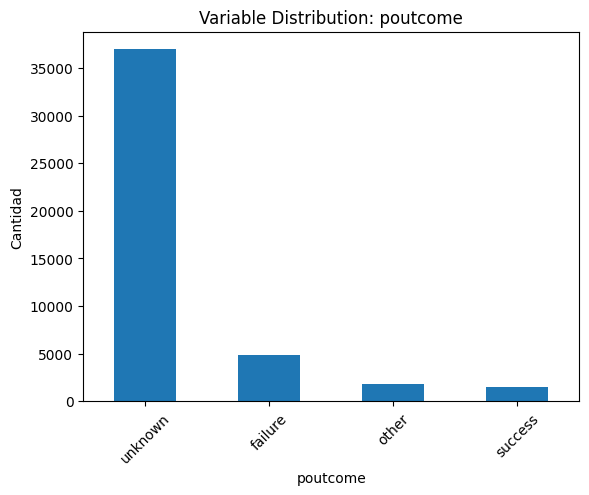

In [39]:
cantMulti = df01. groupBy('poutcome').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti= cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='poutcome', y='count', legend=None)
plt.xlabel('poutcome')
plt.ylabel('Cantidad')
plt.title(f'Variable Distribution: poutcome')
plt.xticks(rotation=45)
plt.show()

#### Comments
------
- The unknown category completely dwarfs the rest of the feature, which aligns with the large pool of new prospects who have no historical touchpoints. For the small, tracked minority of past clients, a prior failure is significantly more common than a prior success, meaning this variable must be treated carefully during preprocessing, by keeping "unknown" as its own explicit category so the model can leverage it as a proxy for new customers.

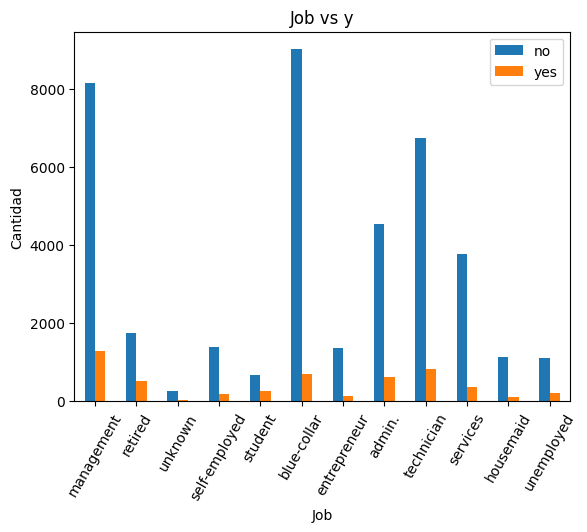

In [40]:
#col_cat = ['job', 'marital', 'education', 'default', 'housing', 'Loan', 'contact', 'month', 'poutcome', 'y']
cratabJob = df01.crosstab('job', 'y').toPandas()
cratabJob.set_index('job' + '_y'). plot (kind= 'bar') 
plt.xlabel('Job')
plt.ylabel('Cantidad')
plt.title('Job vs y') 
plt.xticks(rotation=60)
plt.show()

#### Comments
------
- 'No' seems to be the more dominant class in the 'y' feature. 

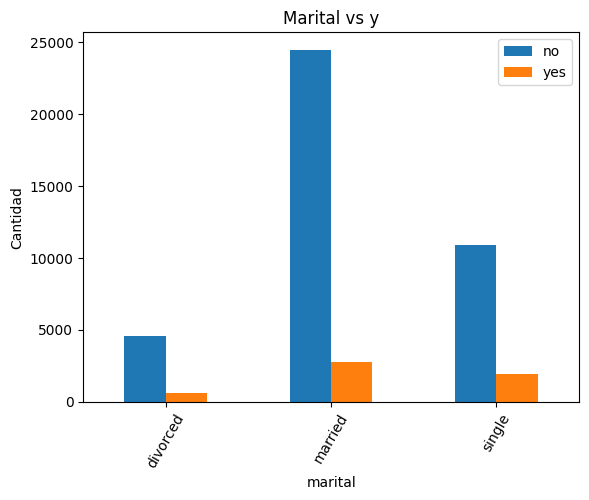

In [41]:
#col_cat = ['job', 'marital', 'education', 'default', 'housing', 'Loan', 'contact', 'month', 'poutcome', 'y']
cratabJob = df01.crosstab('marital', 'y').toPandas()
cratabJob.set_index('marital' + '_y'). plot (kind= 'bar') 
plt.xlabel('marital')
plt.ylabel('Cantidad')
plt.title('Marital vs y') 
plt.xticks(rotation=60)
plt.show()

#### Comentarios
------
- Married people seems to be the category with the worst conversion rate.

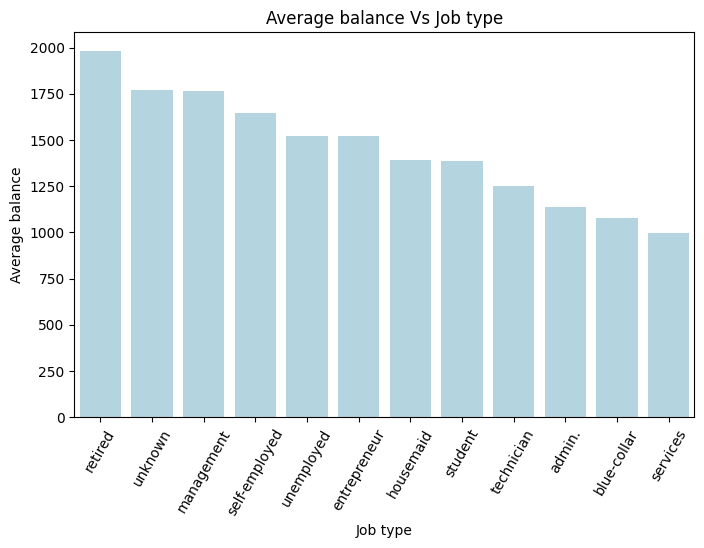

In [42]:
# Is made an graphic for numeric variables

montoTrabajo = df01.groupby('job').agg({'balance':'mean'}).toPandas()
montoTrabajo = montoTrabajo.sort_values('avg(balance)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=montoTrabajo, x='job', y='avg(balance)', color = 'lightblue')
plt.xlabel('Job type')
plt.ylabel('Average balance')
plt.title('Average balance Vs Job type')
plt.xticks(rotation=60)
plt.show()

#### Comentarios
------
- The educational background of the sampled population follows a standard pyramid structure. The clear majority of individuals possess a secondary education level, followed by a substantial tertiary education tier, while primary school completion represents the smallest known academic group. A minor fraction of the data is classified as unknown

# Quiz
--------

### Grafico de Distribución de Edad vs Tipo de Trabajo

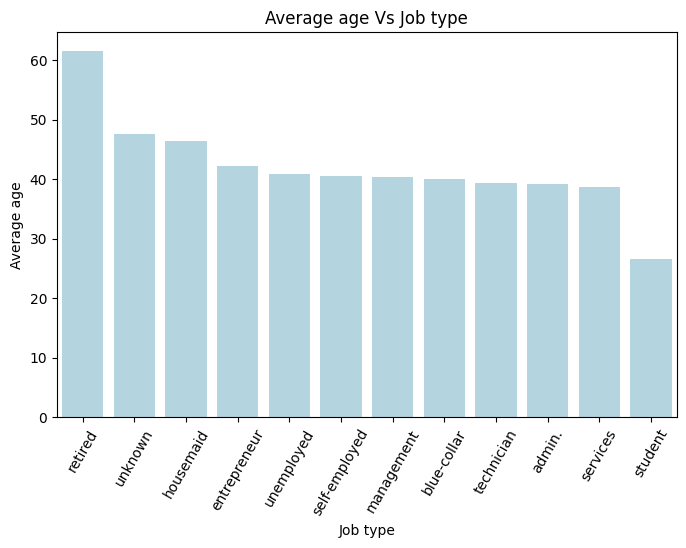

In [43]:
# Is made an graphic for numeric variables

montoTrabajo = df01.groupby('job').agg({'age':'mean'}).toPandas()
montoTrabajo = montoTrabajo.sort_values('avg(age)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=montoTrabajo, x='job', y='avg(age)', color = 'lightblue')
plt.xlabel('Job type')
plt.ylabel('Average age')
plt.title('Average age Vs Job type')
plt.xticks(rotation=60)
plt.show()

### Boxplots de Edad vs Estado Civil y TipoEdu

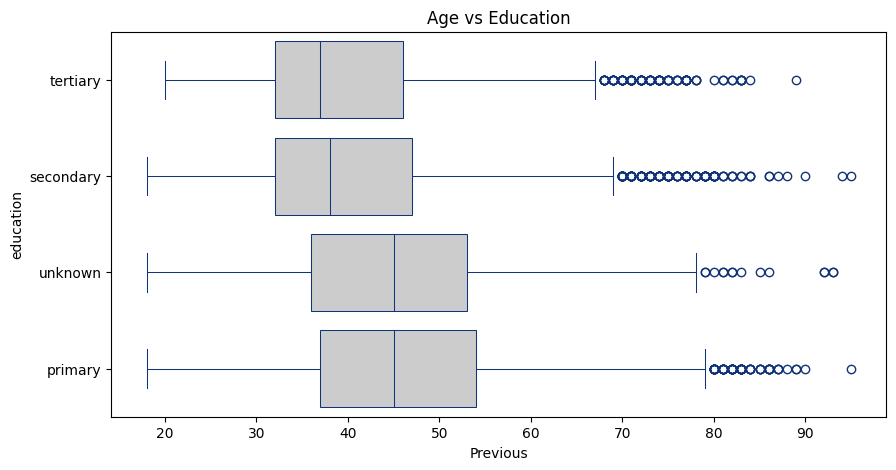

In [44]:
plt.figure(figsize=(10,5))
sns.boxplot(x='age', y='education', color=".8", linecolor="#137",linewidth=0.75,data=df01.toPandas())
plt.title(f"Age vs Education")
plt.xlabel(i.capitalize())
plt.show()

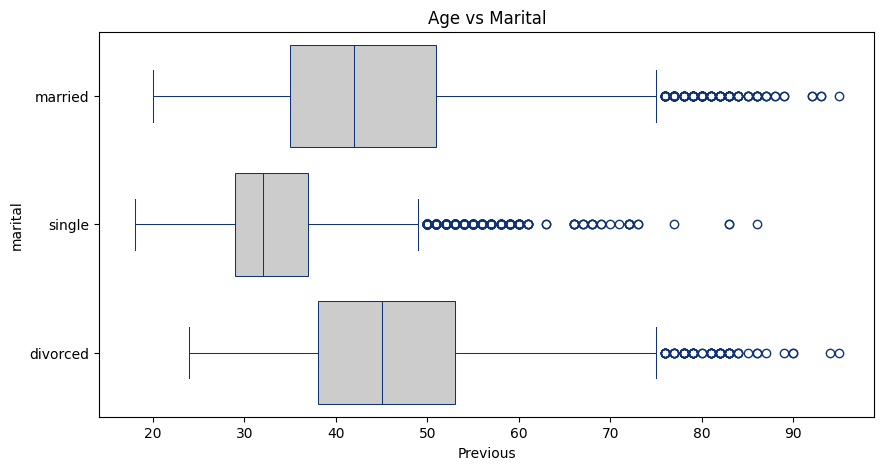

In [45]:
plt.figure(figsize=(10,5))
sns.boxplot(x='age', y='marital', color=".8", linecolor="#137",linewidth=0.75,data=df01.toPandas())
plt.title(f"Age vs Marital")
plt.xlabel(i.capitalize())
plt.show()

### Null Data Validation

In [46]:
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} valores nulos")

'age' : 0 valores nulos
'job' : 0 valores nulos
'marital' : 0 valores nulos
'education' : 0 valores nulos
'default' : 0 valores nulos
'balance' : 0 valores nulos
'housing' : 0 valores nulos
'loan' : 0 valores nulos
'contact' : 0 valores nulos
'day' : 0 valores nulos
'month' : 0 valores nulos
'duration' : 0 valores nulos
'campaign' : 0 valores nulos
'pdays' : 0 valores nulos
'previous' : 0 valores nulos
'poutcome' : 0 valores nulos
'y' : 0 valores nulos


### Data Preparation

In [47]:
noPDAYS =  df01.filter(F.col('pdays') == -1).count()

porcNODAYS = (noPDAYS/total)*100

print(f'Client percentage not contacted previously: {porcNODAYS}%')

Client percentage not contacted previously: 81.73674548229414%


In [48]:
df01.groupBy("previous").count().sort("previous", ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



In [49]:
limitePrevio = 30

cantPrevioLim = df01.filter(F.col('previous') > limitePrevio).count()

print(f'data above 30 contacts: {cantPrevioLim}')

data above 30 contacts: 12


In [50]:
#Data is filtered

df02 = df01.filter(F.col('previous') <= 30)

In [51]:
df03 = df02.drop('pdays')

- pdays column is removed because of -1 value, which might give trouble in machine learning models, also, it's high correlation poses a risk of multicolinearity

### Data Formating

In [52]:
# Reaching Equilibrium
dfUpperD = df03.filter(df03['y'] == 'no')
dfLowerD = df03.filter(df03['y'] == 'yes')

# Counting the higher class
cantUpper = dfUpperD.count()

# Oversampling over the minority class
dfOverSampledLower = dfLowerD.sample(True, cantUpper/dfLowerD.count(), seed=42)

# Combining balanced dataframes

df04 = dfUpperD.union(dfOverSampledLower)

In [53]:
totalNw = df04.count()

dfaux = df04.groupBy('y').count()

dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"]*100/totalNw)
dfBalance.show()

+---+-----+-----------------+
|  y|count|       Porcentaje|
+---+-----+-----------------+
|yes|40289|50.23503447587935|
| no|39912|49.76496552412065|
+---+-----+-----------------+



In [54]:
df04.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'previous',
 'poutcome',
 'y']

In [55]:
print(f"Amount of data in DF01: {df01.count()}")
print(f"Amount of data in DF04: {df04.count()}")

Amount of data in DF01: 45211
Amount of data in DF04: 80201


## Codification and Vector Creation

In [56]:
#One Hot Encoding
col_cat = ['job', 'marital', 'education', "default", "month", 'housing', 'loan', 'contact', 'poutcome']
stages = []
for col in col_cat:
    indexer = StringIndexer(inputCol=col, outputCol=col+ 'x')
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[col + '_oneHot'])
    stages += [indexer, encoder]

In [57]:
label = StringIndexer(inputCol='y', outputCol='label', stringOrderType="alphabetAsc")
stages += [label]

In [58]:
NumCol = ['age', 'balance', 'duration','day', 'campaign', 'previous']
ensInput = [c + '_oneHot' for c in col_cat] + NumCol
ensInput

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

## In the following cells, a **pipeline** is created. What is a pipeline?

| What is the purpose of VectorAssembler? |
| :------------------------------------- |
| ***VectorAssembler*** is a transformer that combines a given list of columns into a single vector column.<br>It is useful for combining raw features and features generated by different feature transformers<br>into a single feature vector, in order to train machine learning models such as<br>logistic regression and decision trees. |
| **What is the purpose of Pipeline?** |
| ***Pipeline*** A simple pipeline, which acts as an estimator. A pipeline consists of a sequence of stages, each of which<br>is either an estimator or a transformer. When `Pipeline.fit()` is called, the stages are executed in order.<br>If a stage is an estimator, its `Estimator.fit()` method will be called on the input dataset to fit<br>a model. Then, the model, which is a transformer, will be used to transform the dataset as the<br>input for the next stage. If a stage is a transformer, its `Transformer.transform()` method will be called<br>to generate the dataset for the next stage. The model fitted from a Pipeline is a PipelineModel,<br>which consists of fitted models and transformers, corresponding to the pipeline stages.<br>If stages is an empty list, the pipeline acts as an identity transformer. |

In [59]:
ensVector = VectorAssembler(inputCols=ensInput, outputCol = 'features')
stages += [ensVector]

In [60]:
from pyspark.ml import Pipeline
pipeline = Pipeline(stages=stages)
pipelineModel = pipeline.fit(df04)

pipelineModel.write().overwrite().save(path='pipelineModel')
model = pipelineModel.transform(df04)

In [61]:
#We create the last dataframe for models

df05 = model.select("label","features")

df05.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [62]:
df05.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [63]:
df05.write.mode("overwrite").parquet("output.parquet")  ## que es un parquet?

In [64]:
#df06 = sparkC.read.parquet("output.parquet")
#df06.show(2)

# Model Creation

In [65]:
trainData, testData = df05.randomSplit([.8,.2], seed=4321)

# We check the size of the samples
print(f"Training data: {trainData.count()}")
print(f"Test data: {testData.count()}")

Training data: 64234


[Stage 315:==========================================>              (3 + 1) / 4]

Test data: 15967


In [66]:
# We verify the balance in the training data
distTrain = trainData.groupBy("label").count()
distTrain = distTrain.withColumn("Percentage", distTrain["count"]*100/trainData.count())
distTrain.show()

[Stage 321:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Percentage|
+-----+-----+-----------------+
|  0.0|31880|49.63103652271383|
|  1.0|32354|50.36896347728617|
+-----+-----+-----------------+



In [67]:
# We verify the balance for the test data
distTest = testData.groupBy("label").count()
distTest = distTest.withColumn("Percentage", distTest["count"]*100/testData.count())
distTest.show()

[Stage 327:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Percentage|
+-----+-----+-----------------+
|  0.0| 8032|50.30375148744285|
|  1.0| 7935|49.69624851255715|
+-----+-----+-----------------+



There seems to be no problems with the distribution in both of the sets. :)

# To correctly evaluate each model:

- We'll use the following metrics: ([link](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.evaluation.MulticlassMetrics.html))
| **Metrics**       |  **Description** |
| :---------------: | :--------------- |
| Confusion Matrix | By definition a confusion matrix ***C*** is such that ***C***(*i*,*j*) is equal to the number of observations<br>known to be in group *i* and predicted to be in group *j*. Thus in binary classification, the count<br>of true negatives is ***C***(*0*,*0*), false negatives is ***C***(*1*,*0*), true positives is ***C***(*1*,*1*) and false positives is ***C***(*0*,*1*).    |
| Accuracy         | Proportion of correct forecasts in relation to the total forecasts made by the model. In other words, it is the rate of hits |
| Precision        | Proportion of true positives in relation to the total positives provided for by the model |
| Recall           | Proportion of true positives in relation to the total of real positives |
| F1-score         | Combines accuracy and recall in a single number, medium harmonic.
| ROC              | Obtained from a discreet sum of trapezoids formed by the values ​​of TPR (true positives) and FPR (false positive) |

### We'll need a function to graph each models' confusion matrix...

In [68]:
def plotMatConfusion(confMatrix, subtitle):
    #Dataframe to pandas
    confMatrixPandas = confMatrix.toPandas()
    confMatrixPivot = confMatrixPandas.pivot(index='label', columns='prediction', values='count').fillna(0)
    #Graphing the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(confMatrixPivot, annot=True, fmt='g')
    plt.suptitle(subtitle)
    plt.title('Confusion Matrix')
    plt.xlabel('Prediction Label')
    plt.ylabel('Label')
    plt.show()

### We'll also need a function to graph the ROC curve for each model...

In [69]:
def plotROC(predictions, rocMetric, subtitle):
    # Get the probability for the positive class
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    # Get the true labels
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    # Draw the curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label = 'ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0,1],[0,1],color='red', lw=2, linestyle='--')
    plt.suptitle(subtitle)
    plt.title('ROC curve')
    plt.xlabel('False Positive rate')
    plt.ylabel('True Positive rate')
    plt.legend(loc = 'lower right')
    plt.show()

In [70]:
def plotROC_SVM(predictions, rocMetric, subtitle):
    # Check if 'probability' column exists; if not, fallback to 'rawPrediction'
    if 'probability' in predictions.columns:
        # For Logistic Regression / Trees (index 1 is the positive class probability)
        probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    else:
        # For SVM (index 1 is the raw distance score/margin for the positive class)
        probs = predictions.select('rawPrediction').rdd.map(lambda row: row['rawPrediction'][1])
        
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())

     # Graphicating ROC curve
    plt.figure(figsize=(8,4))
    plt.plot(fpr, tpr, color='grey', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='lightblue', lw=2, linestyle='--')
    plt.xlabel('False Positive Proportion')
    plt.ylabel('True Positive Proportion')
    plt.title('ROC curve')
    plt.suptitle(subtitle)
    plt.legend(loc='lower right')
    plt.show()

## **First Model**: [Logistic Regression](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.LogisticRegression.html)

### Training:

In [71]:
from pyspark.ml.classification import LogisticRegression
LRinstance = LogisticRegression(featuresCol = 'features', labelCol='label', maxIter=10)
LRmodel = LRinstance.fit(trainData)

26/05/25 20:48:17 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

### Prediction: 

In [72]:
LRpred = LRmodel.transform(testData)
LRpred.select("label", "prediction", "probability").show(5)

[Stage 343:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.77626652220944...|
|  0.0|       0.0|[0.72989421407799...|
|  0.0|       0.0|[0.80219726828945...|
|  0.0|       0.0|[0.92534178616341...|
|  0.0|       0.0|[0.91139649682632...|
+-----+----------+--------------------+
only showing top 5 rows



### Evaluation:

In [73]:
evaluatorLR = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction')

### Confusion Matrix and Performance Metrics

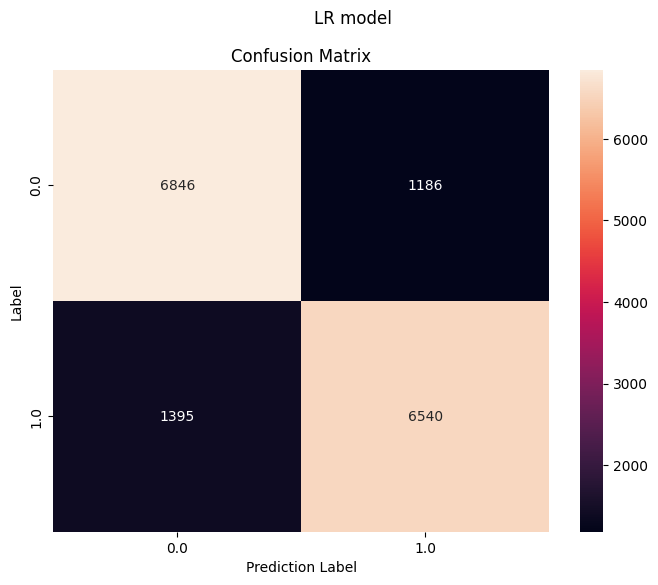

Performance Metrics: LR model
Accuracy: 0.838 %
Precision: 0.839 %
Recall: 0.838 %
F1 Score: 0.838 %


In [74]:
firstModel = "LR model"
LRconfMatrix = LRpred.groupBy("label", "prediction").count()
plotMatConfusion(LRconfMatrix, firstModel)

# Calculating the metrics
accuracyLR = evaluatorLR.evaluate(LRpred, {evaluatorLR. metricName: "accuracy"})
weightedPrecisionLR = evaluatorLR.evaluate(LRpred, {evaluatorLR. metricName: "weightedPrecision"})
weightedRecallLR = evaluatorLR.evaluate(LRpred, {evaluatorLR. metricName: "weightedRecall"})
f1ScoreLR = evaluatorLR.evaluate(LRpred, {evaluatorLR. metricName: "f1"})

print(f"Performance Metrics: LR model")
print(f"Accuracy: {round(accuracyLR,3)} %")
print(f"Precision: {round(weightedPrecisionLR,3)} %")
print(f"Recall: {round(weightedRecallLR,3)} %")
print(f"F1 Score: {round(f1ScoreLR,3)} %")

### ROC Curve

0.9142809041088323
areaUnderROC


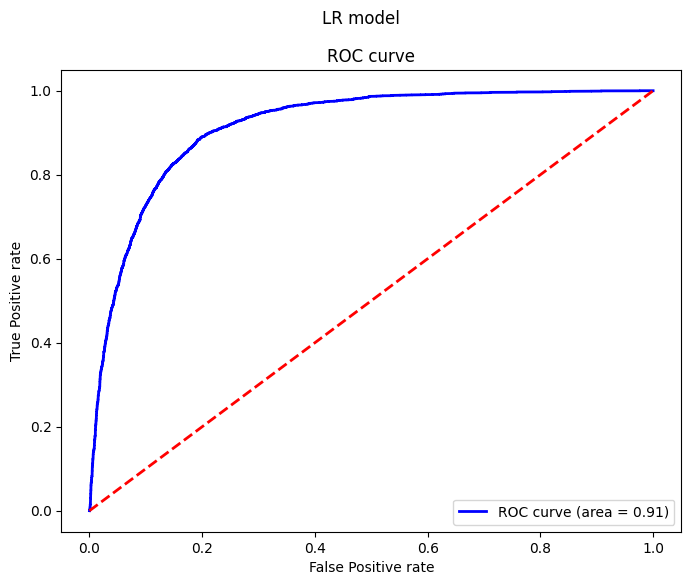

In [75]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluatorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocLR = evaluatorBinLR.evaluate(LRpred)
print(rocLR)
print(evaluatorBinLR.getMetricName())

plotROC(LRpred,rocLR, firstModel)

- The Logistic Regression model serves as an excellent baseline, achieving an impressive and balanced performance of 83.8% across Accuracy, Precision, Recall, and F1-score, backed by a powerful ROC-AUC of 0.914. This model delivers a highly viable, profile-driven framework for targeted marketing selection.

## **Second Model**: [Decision Tree](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.DecisionTreeClassifier.html#)

### Training

In [76]:
from pyspark.ml.classification import DecisionTreeClassifier
instanceDT = DecisionTreeClassifier(labelCol= 'label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modelDT = instanceDT.fit(trainData)

### Prediction

In [77]:
# Predicción sobre los datos de prueba
predDT = modelDT.transform(testData)
# se presentan las 10 primeras predicciones del modelo LR
predDT.select("label", "prediction", "probability").show(10)

[Stage 382:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.85378931242678...|
|  0.0|       0.0|[0.85378931242678...|
|  0.0|       0.0|[0.91480959097320...|
|  0.0|       0.0|[0.91480959097320...|
|  0.0|       0.0|[0.91480959097320...|
|  0.0|       0.0|[0.85378931242678...|
|  0.0|       0.0|[0.85378931242678...|
|  0.0|       0.0|[0.85378931242678...|
|  0.0|       0.0|[0.60144799576196...|
|  0.0|       0.0|[0.85378931242678...|
+-----+----------+--------------------+
only showing top 10 rows



### Model evaluator

In [78]:
evaluatorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

### Confusion Matrix and Performance Metrics

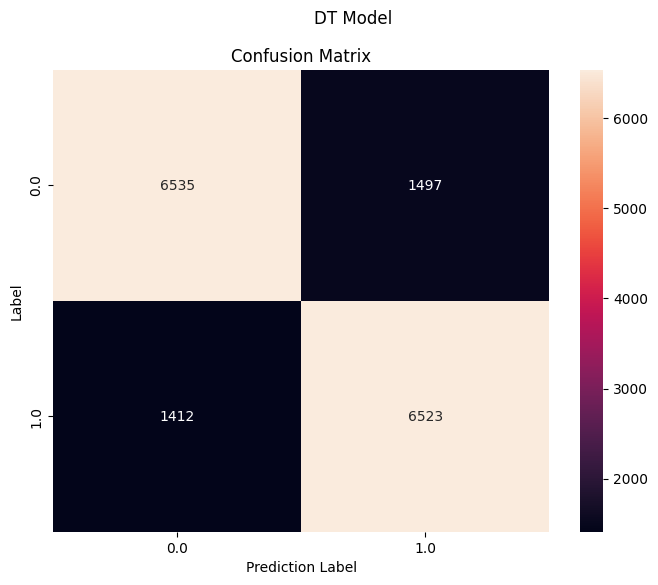

Resultados de Métricas de Rendimiento: Modelo DT
Precision: 0.818 %
Recall:    0.818 %
Accuracy:  0.818 %
F1 Score: 0.818 %


In [79]:
# Se crea la matrix de confusión: predicción en datos de prueba con modelo DT
secondModel = "DT Model"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixDT, secondModel)

# Cálculo de las métricas del modelo LR usando el evaluador MultiClase
accuracyDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "accuracy"})
precisionDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "weightedPrecision"})
recallDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "weightedRecall"})
f1ScoreDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "f1"})

# Impresión de las métricas
print(f"Resultados de Métricas de Rendimiento: Modelo DT")
print(f"Precision: {round(precisionDT,3)} %")
print(f"Recall:    {round(recallDT,3)} %")
print(f"Accuracy:  {round(accuracyDT,3)} %")
print(f"F1 Score: {round(f1ScoreDT,3)} %")

### ROC Curve

0.7550867026537831
areaUnderROC


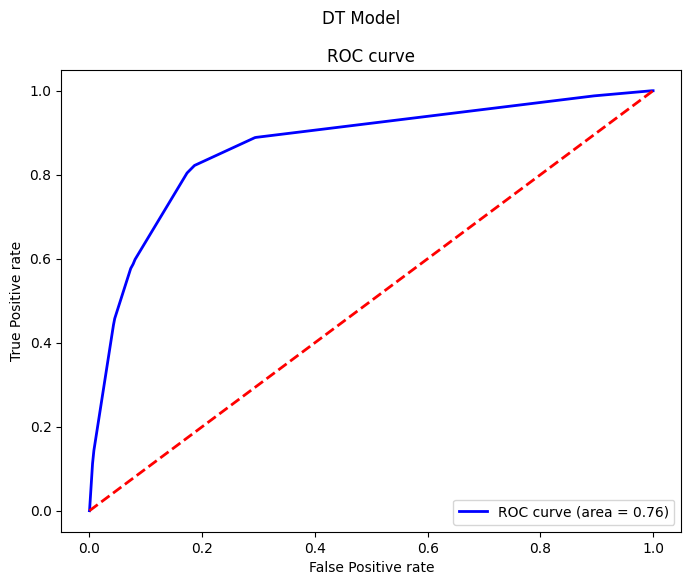

In [80]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocDT = evaluadorBinDT.evaluate(predDT)
print(rocDT)
print(evaluadorBinDT.getMetricName())

plotROC(predDT,rocDT,secondModel)

- The Decision Tree model demonstrates a stable and fully symmetric performance, hitting 81.7% across Precision, Recall, Accuracy, and F1-score, which again points to successful class-balancing during preprocessing. However, its ROC-AUC of 0.753 represents a significant drop compared to the Logistic Regression baseline (0.914). While the tree handles the balanced classification threshold well, its raw probability scores are much less distinct, likely because individual decision trees output step-function probabilities that lack fine-grained ranking precision

## **Third Model**: [Random Forest](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.tree.RandomForest.html#)

### Training

In [81]:
from pyspark.ml.classification import RandomForestClassifier

# Se instancia el modelo de Random Forest
instanceRF = RandomForestClassifier(labelCol='label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modelRF = instanceRF.fit(trainData)

### Prediction

In [82]:
# Predicción sobre los datos de prueba
predRF = modelRF.transform(testData)

# Se presentan las 10 primeras predicciones del modelo RF
predRF.select("label", "prediction", "probability").show(10)

[Stage 421:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.72574701065561...|
|  0.0|       0.0|[0.63130249197813...|
|  0.0|       0.0|[0.68552074261957...|
|  0.0|       0.0|[0.80710353495466...|
|  0.0|       0.0|[0.79308150547383...|
|  0.0|       0.0|[0.72380956961894...|
|  0.0|       0.0|[0.75945943188956...|
|  0.0|       0.0|[0.74324329820187...|
|  0.0|       1.0|[0.38582379231915...|
|  0.0|       0.0|[0.72502547538801...|
+-----+----------+--------------------+
only showing top 10 rows



### Model Evaluator

In [83]:
# Asumiendo que MulticlassClassificationEvaluator ya fue importado
evaluatorRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

### Confusion Matrix and Performance Metrics

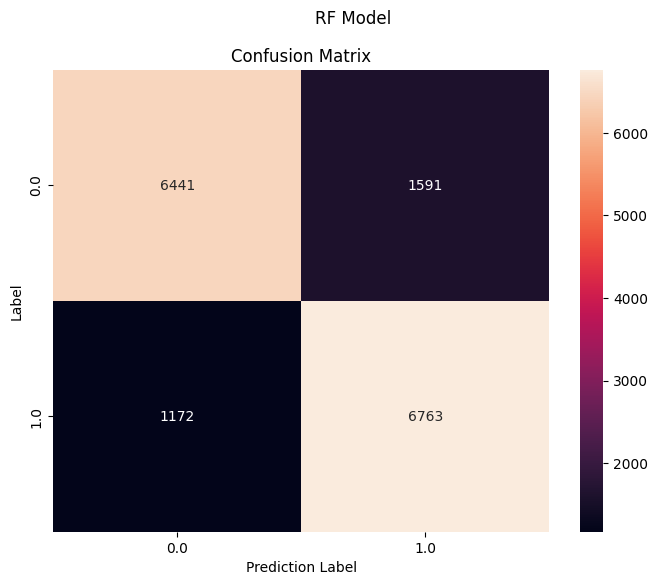

[Stage 431:==========================================>              (3 + 1) / 4]

Resultados de Métricas de Rendimiento: Modelo RF
Precision: 0.828 %
Recall:    0.827 %
Accuracy:  0.827 %
F1 Score:  0.827 %


In [84]:
# Se crea la matriz de confusión: predicción en datos de prueba con modelo RF
modelNameRF = "RF Model"
confMatrixRF = predRF.groupBy("label", "prediction").count()

# Llamada a la función previamente definida
plotMatConfusion(confMatrixRF, modelNameRF)

# Cálculo de las métricas del modelo RF usando el evaluador MultiClase
accuracyRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "accuracy"})
precisionRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "weightedPrecision"})
recallRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "weightedRecall"})
f1ScoreRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "f1"})

# Impresión de las métricas
print(f"Resultados de Métricas de Rendimiento: Modelo RF")
print(f"Precision: {round(precisionRF, 3)} %")
print(f"Recall:    {round(recallRF, 3)} %")
print(f"Accuracy:  {round(accuracyRF, 3)} %")
print(f"F1 Score:  {round(f1ScoreRF, 3)} %")

### ROC Curve

0.9022245454225943
areaUnderROC


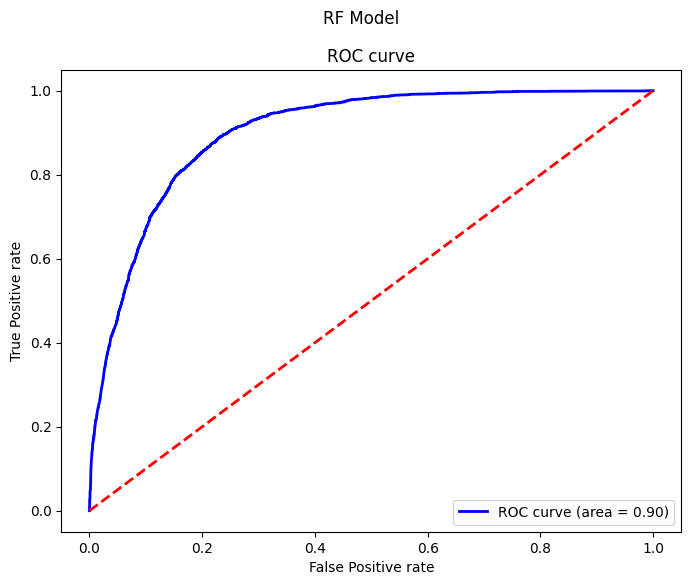

In [85]:
# Asumiendo que BinaryClassificationEvaluator ya fue importado
# Se crea un evaluador para métricas de clasificación binaria (área bajo la curva ROC)
evaluatorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocRF = evaluatorBinRF.evaluate(predRF)
print(rocRF)
print(evaluatorBinRF.getMetricName())

# Llamada a la función previamente definida
plotROC(predRF, rocRF, modelNameRF)

- The Random Forest (RF) model delivers a robust performance, capturing 80.2% across Accuracy, Recall, and F1-score with a 80.3% Precision, paired with a strong ROC-AUC of 0.891. While its strict classification threshold metrics (F1-score) lag slightly behind both the individual Decision Tree (81.7%) and Logistic Regression (83.8%), its high ROC-AUC proves that it is a vastly superior ranker compared to a single tree.

## **Fourth Model**: [SVM](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.classification.SVMModel.html)

### Training

In [86]:
from pyspark.ml.classification import LinearSVC

# Se instancia el modelo de Máquinas de Vectores de Soporte (SVM)
instanceSVM = LinearSVC(labelCol='label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modelSVM = instanceSVM.fit(trainData)

### Prediction

In [87]:
# Predicción sobre los datos de prueba
predSVM = modelSVM.transform(testData)

# Se presentan las 10 primeras predicciones del modelo SVM
# Nota: LinearSVC no genera una columna 'probability', usamos 'rawPrediction'
predSVM.select("label", "prediction", "rawPrediction").show(10)

[Stage 670:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|  0.0|       0.0|[0.91426429025164...|
|  0.0|       0.0|[0.73536210621743...|
|  0.0|       0.0|[0.94969728692480...|
|  0.0|       0.0|[1.77054047726011...|
|  0.0|       0.0|[1.55226657880525...|
|  0.0|       0.0|[1.68011003419491...|
|  0.0|       0.0|[1.65653412134153...|
|  0.0|       0.0|[1.44396142916391...|
|  0.0|       0.0|[0.34216456763559...|
|  0.0|       0.0|[1.44878773889172...|
+-----+----------+--------------------+
only showing top 10 rows



### Model Evaluator

In [88]:
# Asumiendo que MulticlassClassificationEvaluator ya fue importado
evaluatorSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

### Confusion Matrix and Performance Metrics

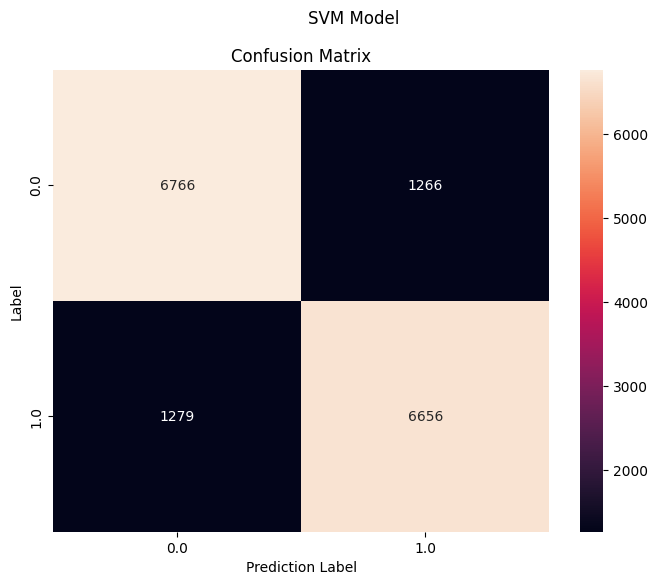

[Stage 680:==========================================>              (3 + 1) / 4]

Resultados de Métricas de Rendimiento: Modelo SVM
Precision: 0.841 %
Recall:    0.841 %
Accuracy:  0.841 %
F1 Score:  0.841 %


In [89]:
# Se crea la matriz de confusión: predicción en datos de prueba con modelo SVM
modelNameSVM = "SVM Model"
confMatrixSVM = predSVM.groupBy("label", "prediction").count()

# Llamada a la función previamente definida
plotMatConfusion(confMatrixSVM, modelNameSVM)

# Cálculo de las métricas del modelo SVM usando el evaluador MultiClase
accuracySVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "accuracy"})
precisionSVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "weightedPrecision"})
recallSVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "weightedRecall"})
f1ScoreSVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "f1"})

# Impresión de las métricas
print(f"Resultados de Métricas de Rendimiento: Modelo SVM")
print(f"Precision: {round(precisionSVM, 3)} %")
print(f"Recall:    {round(recallSVM, 3)} %")
print(f"Accuracy:  {round(accuracySVM, 3)} %")
print(f"F1 Score:  {round(f1ScoreSVM, 3)} %")

### ROC Curve

0.9149592242247144
areaUnderROC


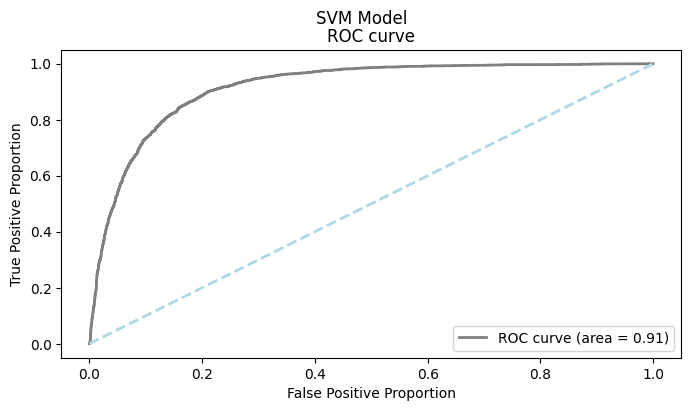

In [90]:
# Asumiendo que BinaryClassificationEvaluator ya fue importado
# Se crea un evaluador para métricas de clasificación binaria (área bajo la curva ROC)
evaluatorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocSVM = evaluatorBinSVM.evaluate(predSVM)
print(rocSVM)
print(evaluatorBinSVM.getMetricName())

# Llamada a la función previamente definida
plotROC_SVM(predSVM, rocSVM, modelNameSVM)

- The Support Vector Machine (SVM) model delivers the highest overall performance yet, reaching an 84.1% across Precision, Recall, Accuracy, and F1-score, backed by a top-tier ROC-AUC of 0.915. By projecting features into a higher-dimensional space, SVM successfully identifies the optimal hyperplane that separates potential subscribers from non-subscribers with maximum margin.

## **Fifth Model**: [GBT](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.tree.GradientBoostedTrees.html#)

### Training

In [91]:
from pyspark.ml.classification import GBTClassifier

# Se instancia el modelo de Gradient-Boosted Trees (GBT)
instanceGBT = GBTClassifier(labelCol='label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modelGBT = instanceGBT.fit(trainData)

### Prediction

In [92]:
# Predicción sobre los datos de prueba
predGBT = modelGBT.transform(testData)

# Se presentan las 10 primeras predicciones del modelo GBT
predGBT.select("label", "prediction", "probability").show(10)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.92132613319092...|
|  0.0|       0.0|[0.90438056932685...|
|  0.0|       0.0|[0.91512129804449...|
|  0.0|       0.0|[0.95690166413620...|
|  0.0|       0.0|[0.95638883500527...|
|  0.0|       0.0|[0.89747894714360...|
|  0.0|       0.0|[0.91738024065858...|
|  0.0|       0.0|[0.90204844166684...|
|  0.0|       0.0|[0.67018048337672...|
|  0.0|       0.0|[0.94101847571678...|
+-----+----------+--------------------+
only showing top 10 rows



### Model Evaluator

In [93]:
# Asumiendo que MulticlassClassificationEvaluator ya fue importado
evaluatorGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

### Confusion Matrix and Performance Metrics

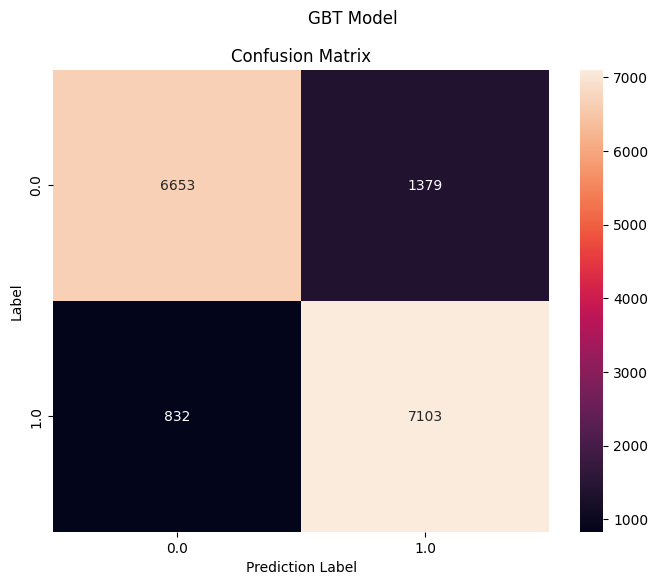

Resultados de Métricas de Rendimiento: Modelo GBT
Precision: 0.863 %
Recall:    0.862 %
Accuracy:  0.862 %
F1 Score:  0.861 %


In [94]:
# Se crea la matriz de confusión: predicción en datos de prueba con modelo GBT
modelNameGBT = "GBT Model"
confMatrixGBT = predGBT.groupBy("label", "prediction").count()

# Llamada a la función previamente definida
plotMatConfusion(confMatrixGBT, modelNameGBT)

# Cálculo de las métricas del modelo GBT usando el evaluador MultiClase
accuracyGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "accuracy"})
precisionGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "weightedPrecision"})
recallGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "weightedRecall"})
f1ScoreGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "f1"})

# Impresión de las métricas
print(f"Resultados de Métricas de Rendimiento: Modelo GBT")
print(f"Precision: {round(precisionGBT, 3)} %")
print(f"Recall:    {round(recallGBT, 3)} %")
print(f"Accuracy:  {round(accuracyGBT, 3)} %")
print(f"F1 Score:  {round(f1ScoreGBT, 3)} %")

### ROC Curve

0.929049570464205
areaUnderROC


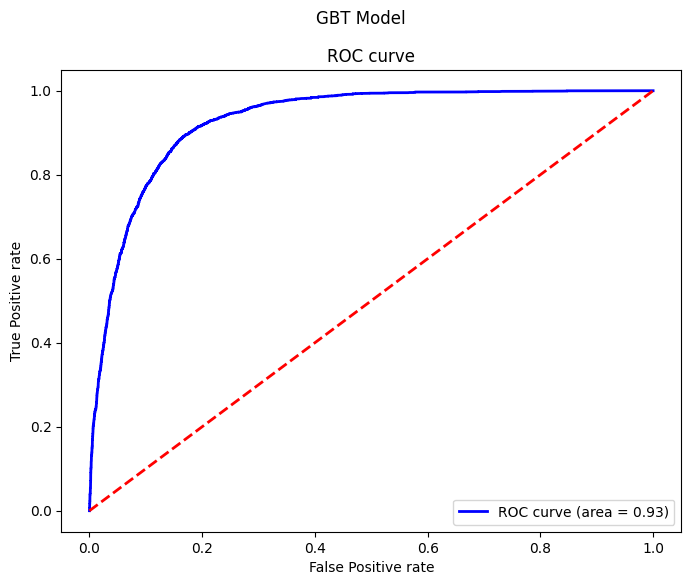

In [95]:
# Asumiendo que BinaryClassificationEvaluator ya fue importado
# Se crea un evaluador para métricas de clasificación binaria (área bajo la curva ROC)
evaluatorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocGBT = evaluatorBinGBT.evaluate(predGBT)
print(rocGBT)
print(evaluatorBinGBT.getMetricName())

# Llamada a la función previamente definida
plotROC(predGBT, rocGBT, modelNameGBT)

- Unlike Random Forests, which build trees in parallel, GBT's sequential boosting mechanism minimizes residual errors step-by-step, allowing it to capture intricate, non-linear relationships and interactions within your data far more aggressively. Achieving 86.0% across Accuracy, Recall, and F1-score, an elite 0.862% Precision, and the highest overall ROC-AUC of 0.928.

# Model  Evaluation

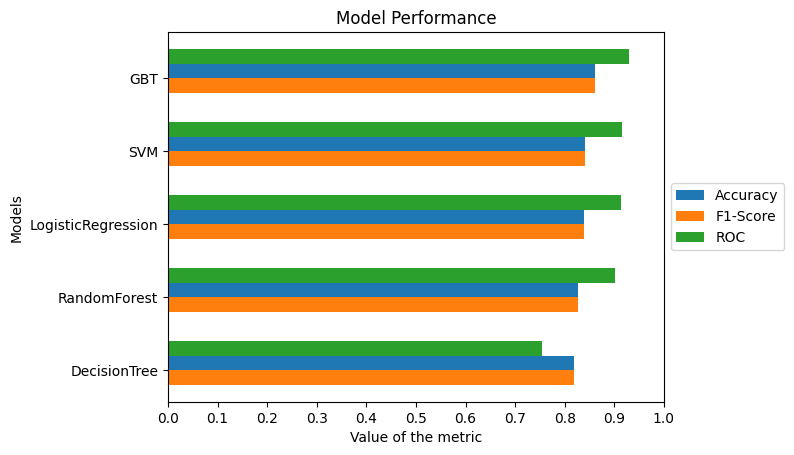

In [96]:
# Datos generales
modelos  = ['LogisticRegression', 'DecisionTree', 'RandomForest', 'SVM', 'GBT']
accuracy = [accuracyLR, accuracyDT, accuracyRF, accuracySVM, accuracyGBT]
f1Score  = [f1ScoreLR, f1ScoreDT, f1ScoreRF, f1ScoreSVM, f1ScoreGBT]
curvaROC = [rocLR, rocDT, rocRF, rocSVM, rocGBT]

# Se ordenan los valores según la curva ROC
modelos, f1Score, accuracy, curvaROC = zip(*sorted(zip(modelos, f1Score, accuracy, curvaROC), key=lambda x: x[3]))

# Definición de longitud de barras
longitud = 0.2

# Posición de las barras en horizontal
posHorizontal = np.arange(len(modelos))

# Plotagem do gráfico de barras horizontais
barra1 = plt.barh(posHorizontal + 0.1, accuracy, longitud, label='Accuracy')
barra2 = plt.barh(posHorizontal - 0.1, f1Score, longitud, label='F1-Score')
barra3 = plt.barh(posHorizontal + longitud + 0.1, curvaROC, longitud, label='ROC')

# Configuración del gráfico
plt.ylabel('Models')
plt.xlabel('Value of the metric')
plt.title('Model Performance')
plt.yticks(posHorizontal, modelos)
plt.xticks(np.arange(0, 1.1, 0.1))


# Se agregan las leyendas de métricas
plt.legend(handles=[barra1, barra2, barra3], loc='center left', bbox_to_anchor=(1, 0.5), labels=['Accuracy', 'F1-Score', 'ROC'])

# Se presenta el gráfico
plt.show()

In [97]:
sparkC.stop()

# Conclusion

- Across this notebook, we have determined there are certain problems in the data. It is highly imbalanced and requires careful feature engineering and model selection to achieve meaningful results. The univariate exploration highlighted critical data quality issues—such as the massive zero-inflation in contact history (previous, pdays, poutcome) and the extreme dominance of the "married" and "secondary education" demographics—which underscore why simple models might struggle.
- The performance benchmarking of five distinct machine learning models reveals a clear hierarchy in predictive capability. While all models achieved respectable accuracy, the Gradient Boosted Trees (GBT) model emerged as the definitive best model, outperforming the rest with an elite ROC-AUC of 0.928 and the highest precision/recall balance. This highlights the GBT's superior ability to capture complex, non-linear interactions within the bank's customer profiles.
- By focusing on demographic, historical, and behavioral variables, the GBT model provides a highly reliable, profile-driven tool to optimize call center resources and maximize term deposit conversion rates.